# Preparing surface data

* See what's available

In [1]:
import neuromaps.datasets

surfaces = ['fsaverage', 'fsLR', 'civet']
[neuromaps.datasets.available_annotations(space = surface)  for surface in surfaces]

/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[[('abagen', 'genepc1', 'fsaverage', '10k'),
  ('beliveau2017', 'az10419369', 'fsaverage', '164k'),
  ('beliveau2017', 'cimbi36', 'fsaverage', '164k'),
  ('beliveau2017', 'cumi101', 'fsaverage', '164k'),
  ('beliveau2017', 'dasb', 'fsaverage', '164k'),
  ('beliveau2017', 'sb207145', 'fsaverage', '164k'),
  ('norgaard2021', 'flumazenil', 'fsaverage', '164k')],
 [('hcps1200', 'megalpha', 'fsLR', '4k'),
  ('hcps1200', 'megbeta', 'fsLR', '4k'),
  ('hcps1200', 'megdelta', 'fsLR', '4k'),
  ('hcps1200', 'meggamma1', 'fsLR', '4k'),
  ('hcps1200', 'meggamma2', 'fsLR', '4k'),
  ('hcps1200', 'megtheta', 'fsLR', '4k'),
  ('hcps1200', 'megtimescale', 'fsLR', '4k'),
  ('hcps1200', 'myelinmap', 'fsLR', '32k'),
  ('hcps1200', 'thickness', 'fsLR', '32k'),
  ('hill2010', 'devexp', 'fsLR', '164k'),
  ('hill2010', 'evoexp', 'fsLR', '164k'),
  ('margulies2016', 'fcgradient01', 'fsLR', '32k'),
  ('margulies2016', 'fcgradient02', 'fsLR', '32k'),
  ('margulies2016', 'fcgradient03', 'fsLR', '32k'),
  ('marguli

In [2]:
list_of_surface_maps = [neuromaps.datasets.available_annotations(space = 'fsaverage')[0]] +\
                       neuromaps.datasets.available_annotations(space = 'fsLR') + \
                       neuromaps.datasets.available_annotations(space = 'civet')
del list_of_surface_maps[13:22]

In [3]:
list_of_surface_maps

[('abagen', 'genepc1', 'fsaverage', '10k'),
 ('hcps1200', 'megalpha', 'fsLR', '4k'),
 ('hcps1200', 'megbeta', 'fsLR', '4k'),
 ('hcps1200', 'megdelta', 'fsLR', '4k'),
 ('hcps1200', 'meggamma1', 'fsLR', '4k'),
 ('hcps1200', 'meggamma2', 'fsLR', '4k'),
 ('hcps1200', 'megtheta', 'fsLR', '4k'),
 ('hcps1200', 'megtimescale', 'fsLR', '4k'),
 ('hcps1200', 'myelinmap', 'fsLR', '32k'),
 ('hcps1200', 'thickness', 'fsLR', '32k'),
 ('hill2010', 'devexp', 'fsLR', '164k'),
 ('hill2010', 'evoexp', 'fsLR', '164k'),
 ('margulies2016', 'fcgradient01', 'fsLR', '32k'),
 ('mueller2013', 'intersubjvar', 'fsLR', '164k'),
 ('raichle', 'cbf', 'fsLR', '164k'),
 ('raichle', 'cbv', 'fsLR', '164k'),
 ('raichle', 'cmr02', 'fsLR', '164k'),
 ('raichle', 'cmrglc', 'fsLR', '164k'),
 ('sydnor2021', 'SAaxis', 'fsLR', '32k'),
 ('xu2020', 'FChomology', 'fsLR', '32k'),
 ('xu2020', 'evoexp', 'fsLR', '32k'),
 ('reardon2018', 'scalinghcp', 'civet', '41k'),
 ('reardon2018', 'scalingnih', 'civet', '41k'),
 ('reardon2018', 'scalin

* Coregister everything to fsLR-4k midthickness

In [78]:
from interpmodules import helpers
import nibabel as nb

fs4k = neuromaps.datasets.fetch_atlas(atlas='fsLR', density='4k')

path_l = fs4k['midthickness'].L
mesh_l= helpers.gii_to_polydata((nb.load(path_l).darrays[0].data, nb.load(path_l).darrays[1].data))

path_r = fs4k['midthickness'].R
mesh_r= helpers.gii_to_polydata((nb.load(path_r).darrays[0].data, nb.load(path_r).darrays[1].data))

In [5]:
import numpy as np
from neuromaps import transforms,images

for input_map in list_of_surface_maps:
    
    ref, desc, space, density = input_map

    data = neuromaps.datasets.fetch_annotation(source=ref, desc=desc, space=space, den=density, hemi='L', verbose=0)
    if ref == 'hill2010':
            data = neuromaps.datasets.fetch_annotation(source=ref, desc=desc, space=space, den=density, hemi='R', verbose=0)
    
    medial = np.where(np.isnan(nb.load(data).darrays[0].data))[0]

    if medial.shape[0] != 0:
        vals = nb.load(data).darrays[0].data
        vals[ medial ] = 0
        data = images.construct_shape_gii(data=vals)
        
    resampled_map = np.zeros(mesh_l.n_points)
    
    if ref == 'hill2010': resampled_map = transforms.fslr_to_fslr(data=data, target_density = '4k', hemi='R', method = 'linear')
    elif space == 'fsLR':
        resampled_map = transforms.fslr_to_fslr(data=data, target_density = '4k', hemi='L', method = 'linear')
    elif space == 'fsaverage':
        resampled_map = transforms.fsaverage_to_fslr(data=data, target_density = '4k', hemi = 'L', method = 'linear')
    elif space == 'civet':
        resampled_map = transforms.civet_to_fslr(data=data, target_density = '4k', hemi = 'L', method = 'linear')
    

    mesh_l[ref + "_" + desc] = resampled_map[0].darrays[0].data

* Visualize the data maps

Loaded aesthetics module


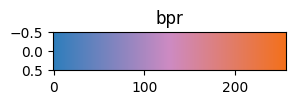

In [6]:
# colour palette
from figs_config import *

bpr,_ = three_colours_gradient(lo=plt.cm.Blues(0.7), mid=plt.cm.PuRd(0.4), hi=plt.cm.Oranges(0.6), plot=False)
show_colour_scheme(bpr, "bpr")

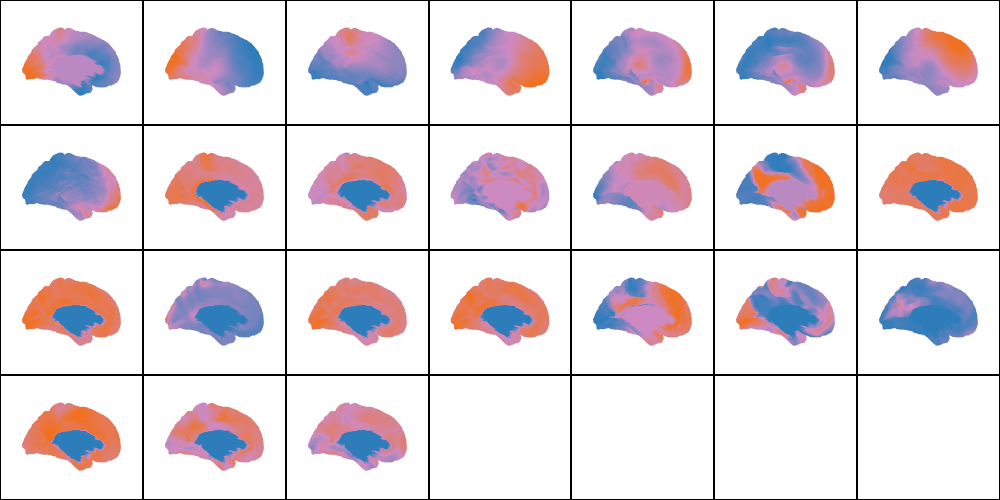

In [7]:
import pyvista as pv
import copy

pl = pv.Plotter(shape=(4,7), window_size = (1000, 500))

for mi,map_name in enumerate(mesh_l.array_names):
    pl.subplot(mi//7,mi%7)
    tmp = copy.copy(mesh_l)
    actor = pl.add_mesh(tmp, scalars = map_name, cmap = bpr, **mesh_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')


* Remove medial wall

In [8]:
medial_mask = []
masked_maps = ['abagen_genepc1', 'hcps1200_myelinmap', 'hcps1200_thickness', 'hill2010_devexp','hill2010_evoexp', 'margulies2016_fcgradient01', \
              'mueller2013_intersubjvar', 'raichle_cbf',
 'raichle_cbv',
 'raichle_cmr02',
 'raichle_cmrglc',
 'sydnor2021_SAaxis',]
for map_name in masked_maps:
    medial_mask.append(np.where(mesh_l[map_name] == 0)[0])

In [9]:
final_medial_mask = np.unique(np.concatenate(medial_mask))

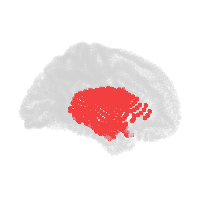

In [10]:
pl = pv.Plotter(window_size = (200,200))

pl.add_points(mesh_l.points[final_medial_mask], color = 'red', **point_aes)
pl.add_points(mesh_l.points, opacity = .3, color = 'lightgray', **point_aes)
pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

In [11]:
# reduce the mesh
reduced_mesh = mesh_l.remove_points(final_medial_mask)[0]

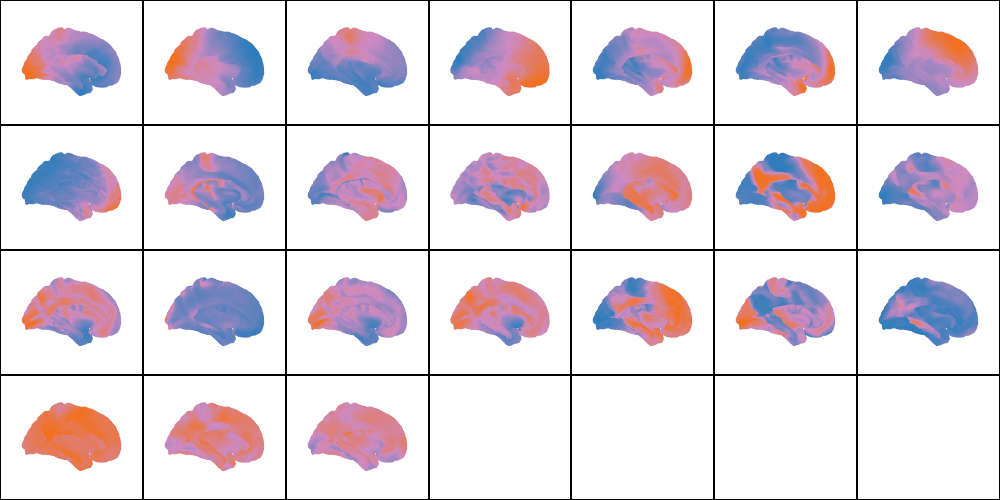

In [12]:
import pyvista as pv
import copy

pl = pv.Plotter(shape=(4,7), window_size = (1000, 500))

for mi,map_name in enumerate(reduced_mesh.array_names):
    pl.subplot(mi//7,mi%7)
    tmp = copy.copy(reduced_mesh)
    actor = pl.add_mesh(tmp, scalars = map_name, cmap = bpr, **mesh_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

In [15]:
import joblib
joblib.dump(reduced_mesh, projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

['..//data/fsLR-4k_reduced-midthickness_neuromaps.pkl']

* Make matching REDUCED midthickness and sphere meshes

In [26]:
fs4k_sphere = neuromaps.datasets.fetch_atlas(atlas='fsLR', density='4k')
sphere_path = fs4k_sphere['sphere'].L
sphere = helpers.gii_to_polydata((nb.load(sphere_path).darrays[0].data, nb.load(sphere_path).darrays[1].data))

reduced_sphere = sphere.remove_points(final_medial_mask)[0]

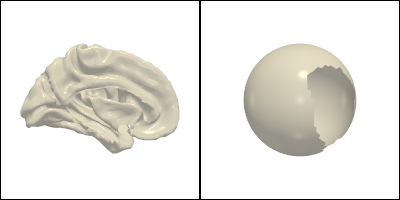

In [57]:
eggshell = "#F0EAD6"
pl = pv.Plotter(shape = (1,2), window_size = (400,200))
pl.subplot(0,0)
pl.add_mesh(reduced_mesh, color = eggshell, smooth_shading = True, diffuse=.6, ambient = .4, specular=.3)
pl.camera_position = 'yz'
pl.subplot(0,1)
pl.add_mesh(reduced_sphere, color = eggshell, smooth_shading=True, diffuse=.6, ambient = .4, specular=.3)
pl.camera_position = 'yz'
pl.show(jupyter_backend='static')

# Subsampling surface data

In [16]:
import neuromaps.points
from scipy import sparse

In [17]:
def get_parcel_centroids(surfinfo, parc):

    centroids = []
    
    vertices, faces = surfinfo
    labels = parc

    for lab in np.unique(labels):
        mask = labels == lab
        inds, = np.where(mask)
        roi = _geodesic_parcel_centroid(vertices, faces, inds)
        centroids.append(roi)

    return np.vstack(centroids)

In [18]:
def _geodesic_parcel_centroid(vertices, faces, inds):
    '''
    simplified from neuromaps.nulls
    '''
    mask = np.ones(len(vertices), dtype=bool)
    mask[inds] = False
    mat = neuromaps.points.make_surf_graph(vertices, faces, mask=mask)
    paths = sparse.csgraph.dijkstra(mat, directed=False, indices=inds)[:, inds]

    # the selected vertex is the one with the minimum average shortest path
    # to the other vertices in the parcel
    roi = vertices[inds[paths.mean(axis=1).argmin()]]

    return roi

* Load parcellation

In [19]:
import abagen
import neuromaps.transforms
import nibabel as nb
import pandas as pd

dsk_orig = abagen.fetch_desikan_killiany(surface=True)
labels_orig = nb.load(dsk_orig['image'][0]).darrays[0].data
df = pd.read_csv( dsk_orig['info'] )

dsk_resampled = neuromaps.transforms.fsaverage_to_fslr(
    nb.load(dsk_orig['image'][0]), 
    target_density = '4k', 
    hemi = 'L', 
    method = 'nearest'
)

dsk_parc = dsk_resampled[0].darrays[0].data.astype(np.int32)

In [81]:
mesh_l.clear_data()
mesh_l['dsk33'] = dsk_parc

reduced_mesh_parc = mesh_l.remove_points(final_medial_mask)[0]

In [82]:
dsk_centroids = get_parcel_centroids(
    surfinfo = (nb.load(path_l).darrays[0].data,
                nb.load(path_l).darrays[1].data), 
    parc=dsk_parc)

In [88]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

n = dsk_parc.max()
cmap = plt.cm.cubehelix
colors = cmap(np.linspace(0.15, .9, n))
np.random.seed(321) # scramble
dsk_colours = colors[np.random.choice(n,n)]
discrete_cmap = mcolors.ListedColormap(np.vstack([np.ones(4),dsk_colours]), name="wcuhe34")

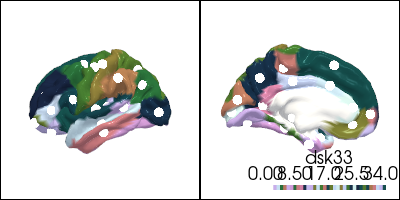

In [95]:
import pyvista as pv

pl0 = pv.Plotter(shape = (1,2), window_size = (400, 200))

import numpy as np
from scipy.ndimage import gaussian_filter1d  # if available

pl0.subplot(0,0)
centroid_coords_pv = pv.PolyData(dsk_centroids)
pl0.add_points(centroid_coords_pv.rotate_z(180), point_size = 10, color = 'w', **point_aes)
pl0.add_mesh(mesh_l.rotate_z(180), scalars = 'dsk33', cmap = discrete_cmap, smooth_shading = True,\
             specular = 0.5, diffuse = .8, ambient=.4, show_scalar_bar=False, categories =True, n_colors = 35, style = 'surface',interpolate_before_map=False)

pl0.camera_position = 'yz'

pl0.subplot(0,1)
pl0.add_points(centroid_coords_pv, color = 'w', point_size = 10,  **point_aes)
pl0.add_mesh(mesh_l, scalars = 'dsk33', cmap = discrete_cmap, smooth_shading = True,specular = 0.5, diffuse = .8, ambient=.4, show_scalar_bar=True, categories =True, n_colors = 35,interpolate_before_map=False)

pl0.camera_position = 'yz'

pl0.show(jupyter_backend = 'static')
#pl0.save_graphic(projdir + '/figs/main/dsk33_centroids_and_parcellation.svg')

In [83]:
dsk_centroids_sphere = get_parcel_centroids(surfinfo = (nb.load(sphere_path).darrays[0].data, nb.load(sphere_path).darrays[1].data), \
                                            parc=dsk_parc)

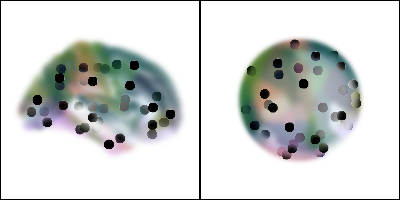

In [89]:
import pyvista as pv

pl = pv.Plotter(shape=(1,2), window_size = (400, 200))

pl.subplot(0,0)
actor0 = pl.add_points(dsk_centroids, color = 'k', render_points_as_spheres=True, point_size = 10, show_scalar_bar=False)
actor0 = pl.add_points(mesh_l.points, style = 'points_gaussian', point_size = 20, \
                      scalars = dsk_parc.astype(int), cmap = discrete_co, \
                      show_scalar_bar=False, smooth_shading = True, opacity = 0.1)
pl.camera_position = 'yz'

pl.subplot(0,1)
actor2 = pl.add_points(dsk_centroids_sphere, color = 'k', render_points_as_spheres=True, point_size = 10, show_scalar_bar=False)
actor2 = pl.add_points(mesh_sphere.points, style = 'points_gaussian', point_size = 20, \
                      scalars = dsk_parc.astype(int), cmap = 'cubehelix_r', \
                      show_scalar_bar=False, smooth_shading = True, opacity = 0.1)
pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

In [25]:
joblib.dump( (df['label'][:34].to_list(), dsk_parc, dsk_centroids), projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')
joblib.dump( (df['label'][:34].to_list(), dsk_parc, dsk_centroids_sphere), projdir + '/data/fsLR-4k_sphere_parc-dsk33.pkl')

['..//data/fsLR-4k_sphere_parc-dsk33.pkl']

# DSK-seeded sampling

In [96]:
niters = 100

labels = ("known_coords", "known_verts", "unknown_coords", "unknown_verts")

for percentage in test_percentages:
    samp_dsk = helpers.get_training_set(mesh=reduced_mesh_parc,\
                                    sphere=reduced_sphere,\
                                    pct_split = percentage,\
                                    n_iters = niters, parcellation_name='dsk33',\
                                    sphere_foci = dsk_centroids_sphere,
                                    method = 'focaldiffuse')
    joblib.dump( (labels, samp_dsk), projdir + f'/data/sampling/fsLR-4k_reduced-midthickness_samp-dsk33_pct-{percentage}_iters-{niters}.pkl')